# MiMo-V2.6-Flash-RL on 3× CMP 170HX (SM80) — vLLM PP3, Gen2 x16 behind PLX switches

| Metric | Value |
|---|---|
| Decode, c=1, greedy (P1 median, 5 workloads) | **113.8 tok/s** PP3 + MTP k=2 (was 117.7) · **74.6 tok/s** PP3 (was 75.5) |
| Best aggregate | 518 tok/s at c=32 (PP3 + MTP k=2) |
| Prefill | 4,082 tok/s at 20,289 prompt tokens (c=1, uncached) |
| TTFT | 4.97 s at 20,289 prompt tokens |

![decode and aggregate vs the 2026-09-24 x16 run](../assets/charts/2026-10-01-mimo-v2.6-flash-3card-pp3-vllm.png)

```bash
hf download XiaomiMiMo/MiMo-V2.6-Flash-RL --revision 5711b268169967567844e1e560e8a3966da959b1 --local-dir <weights>
```

[Previous run and full lane history: 2026-09-22 MiMo notebook](2026-09-22-mimo-v2.6-flash-4card-pp4-vllm.ipynb)

In [1]:
# --- Status cell -------------------------------------------------------
# LIVE = False replays the committed receipts. The live path is the previous
# notebook's tools (gate.py, bench_mimo.py, conc_sweep.py) against a server
# started as in section 3.
import os

EXPERIMENT = "2026-10-01-mimo-v2.6-flash-3card-pp3-vllm"
RESULTS_DIR = os.path.join("..", "results", EXPERIMENT)
PRIOR_DIR = os.path.join("..", "results/2026-09-22-mimo-v2.6-flash-4card-pp4-vllm/receipts/x16")
LIVE = False
print("LIVE =", LIVE, "| receipts:", RESULTS_DIR, "| prior:", PRIOR_DIR)

LIVE = False | receipts: ../results/2026-10-01-mimo-v2.6-flash-3card-pp3-vllm | prior: ../results/2026-09-22-mimo-v2.6-flash-4card-pp4-vllm/receipts/x16


In [2]:
import json, statistics as st
from IPython.display import display, Markdown

CFGS = ['pp3', 'pp3-mtp2']
LABEL = {"pp3": "PP3", "pp3-mtp2": "PP3 + MTP k=2"}


def J(*p):
    return json.load(open(os.path.join(*p)))


def table(headers, rows):
    out = ["| " + " | ".join(headers) + " |", "|" + "|".join(["---"] * len(headers)) + "|"]
    out += ["| " + " | ".join(str(c) for c in r) + " |" for r in rows]
    display(Markdown("\n".join(out)))


def p1m(d):
    return st.median(v["median_decode_tok_s"] for v in d["runs"].values())


def p2m(d):
    return st.median(r["decode_tok_s"] for r in d["runs"]["longform"]["reps"][1:])


new = {c: {k: J(RESULTS_DIR, "runs", c, k + ".json") for k in ("p1", "p2", "conc", "gate", "boot")} for c in CFGS}
old = {c: {k: J(PRIOR_DIR, c, k + ".json") for k in ("p1", "p2", "conc", "gate")} for c in CFGS}
pre = {}
for c in CFGS:
    p = os.path.join(RESULTS_DIR, "runs", c, "prefill.jsonl")
    pre[c] = [json.loads(l) for l in open(p)] if os.path.exists(p) else []
env = J(RESULTS_DIR, "environment.json")
print("configs:", CFGS)

configs: ['pp3', 'pp3-mtp2']


## 1. TL;DR

Same image, patches, launch arguments and protocol as the 2026-09-24 three-card x16 re-run
(`receipts/x16/` of the previous notebook); what changed is the host. The earlier run had three
cards on direct CPU root ports at **Gen1 x16** in a VM; this one has three cards at **Gen2 x16**
behind two PLX PEX 8747 switches, bare metal, no P2P, same 180 W cap.

**Measured verdict: no gain from the faster link.** Single-stream decode is within 1–3 % of the
prior run (PP3 74.6 vs 75.5, PP3 + MTP k=2 113.8 vs 117.7 tok/s greedy), and aggregate at c=32 is
450 vs 455 (PP3) and 518 vs 561 (MTP). PP decode is HBM-bound and hands only small activations
between stages, so doubling the link rate does not show. All gates 4/4 correct, no thermal stop,
uncached prefill 4,107 tok/s (PP3) / 4,082 tok/s (MTP) at ~20.3k prompt tokens.

In [3]:
rows = []
for c in CFGS:
    rows.append([LABEL[c], "measured 2026-10-01", "all correct" if all(g["correct"] for g in new[c]["gate"]) else "FAIL",
                 f"{p1m(new[c]['p1']):.1f}", f"{p2m(new[c]['p2']):.1f}",
                 max(l["aggregate_tok_s"] for l in new[c]["conc"]["levels"]), new[c]["boot"]["cold_boot_s"]])
    rows.append([LABEL[c], "2026-09-24 x16 (prior)", "all correct" if all(g["correct"] for g in old[c]["gate"]) else "FAIL",
                 f"{p1m(old[c]['p1']):.1f}", f"{p2m(old[c]['p2']):.1f}",
                 max(l["aggregate_tok_s"] for l in old[c]["conc"]["levels"]), "—"])
table(["Config", "Run", "Gate (4 prompts × 3)", "P1 greedy c=1 (tok/s)", "P2 T=1.0 c=1 (tok/s)", "Best aggregate (tok/s)", "Cold boot (s)"], rows)
table(["Pin", "Value"], list(env.items()))

| Config | Run | Gate (4 prompts × 3) | P1 greedy c=1 (tok/s) | P2 T=1.0 c=1 (tok/s) | Best aggregate (tok/s) | Cold boot (s) |
|---|---|---|---|---|---|---|
| PP3 | measured 2026-10-01 | all correct | 74.6 | 73.8 | 450.38 | 380 |
| PP3 | 2026-09-24 x16 (prior) | all correct | 75.5 | 74.9 | 454.6 | — |
| PP3 + MTP k=2 | measured 2026-10-01 | all correct | 113.8 | 86.9 | 518.45 | 420 |
| PP3 + MTP k=2 | 2026-09-24 x16 (prior) | all correct | 117.7 | 90.1 | 561.33 | — |

| Pin | Value |
|---|---|
| cards | 3x CMP 170HX (GA100, SM80), memory-unlocked to 64 GB, 180 W limit |
| pcie | Gen2 x16 each; two cards behind one PLX PEX 8747 switch, one behind a second; same CPU socket; bare metal; no P2P |
| driver | NVIDIA open 615.71.09 + host-side cmpunlocker (upstream 88e39ce) + BAR1-resize serialization patch |
| image | ghcr.io/pixelml/club-170hx@sha256:62f612b49614523e6a46e1493d35d3efd1f363917129d38cc923a31053693bfb (tag vllm-glm53-sm80-pp-20260905) |
| model | XiaomiMiMo/MiMo-V2.6-Flash-RL @ 5711b268169967567844e1e560e8a3966da959b1 (65 shards, 172.9 GB) |
| launch | VLLM_PP_LAYER_PARTITION=17,16,15; --pipeline-parallel-size 3 --gpu-memory-utilization 0.97 --max-model-len 32768 --max-num-seqs 32 --reasoning-parser mimo; MTP run adds VLLM_USE_V2_MODEL_RUNNER=1 and mimo_mtp k=2 |
| patch_mounts | mimo_v2.py (+ mimo_v2_mtp.py for MTP) from results/2026-09-22-mimo-v2.6-flash-4card-pp4-vllm/patches |
| cooling | forced airflow, chassis fans fixed at full duty during the runs; 80 C core / new-Xid stop guard |

## 2. Visible results

### P1 per workload (greedy, 512 tokens, median of 3; tok/s)

In [4]:
for c in CFGS:
    rows = [[w, v["median_decode_tok_s"], old[c]["p1"]["runs"][w]["median_decode_tok_s"], v["flagged_reps"]] for w, v in new[c]["p1"]["runs"].items()]
    display(Markdown(f"**{LABEL[c]}**"))
    table(["Workload", "This run (tok/s)", "Prior x16 run (tok/s)", "Repeat-flagged reps"], rows)

**PP3**

| Workload | This run (tok/s) | Prior x16 run (tok/s) | Repeat-flagged reps |
|---|---|---|---|
| code | 74.56 | 75.47 | [] |
| json | 76.32 | 77.2 | [] |
| counting | 74.42 | 75.34 | [] |
| math | 74.3 | 75.3 | [] |
| prose | 74.58 | 75.6 | [] |

**PP3 + MTP k=2**

| Workload | This run (tok/s) | Prior x16 run (tok/s) | Repeat-flagged reps |
|---|---|---|---|
| code | 116.2 | 120.28 | [] |
| json | 120.03 | 123.42 | [] |
| counting | 109.09 | 112.68 | [] |
| math | 113.85 | 117.66 | [] |
| prose | 100.07 | 102.7 | [] |

### Concurrency (256 tokens, T=1.0, `ignore_eos`, 2 rounds; aggregate tok/s)

In [5]:
levels = sorted({l["concurrency"] for c in CFGS for l in new[c]["conc"]["levels"]})
rows = []
for lv in levels:
    r = [lv]
    for c in CFGS:
        n = {l["concurrency"]: l["aggregate_tok_s"] for l in new[c]["conc"]["levels"]}
        o = {l["concurrency"]: l["aggregate_tok_s"] for l in old[c]["conc"]["levels"]}
        r += [n.get(lv, "not run"), o.get(lv, "—")]
    rows.append(r)
table(["Concurrency"] + [f"{LABEL[c]} {w}" for c in CFGS for w in ("this run", "prior")], rows)

| Concurrency | PP3 this run | PP3 prior | PP3 + MTP k=2 this run | PP3 + MTP k=2 prior |
|---|---|---|---|---|
| 1 | 72.23 | 73.34 | 96.13 | 95.58 |
| 4 | 121.94 | 105.43 | 217.59 | 167.4 |
| 8 | 228.91 | 235.24 | 256.17 | 304.07 |
| 16 | 271.59 | 275.08 | 388.73 | 386.0 |
| 32 | 450.38 | 454.6 | 518.45 | 561.33 |

### Prefill (uncached unique prompt, `max_tokens=1`, c=1)

In [6]:
rows = [[LABEL[c], r["sample"], r["prompt_tokens"], r["ttft_s"], r["prefill_tok_s"]] for c in CFGS for r in pre[c]]
table(["Config", "Sample", "Prompt tokens", "TTFT (s)", "Prefill (tok/s)"], rows) if rows else print("prefill: untested")

| Config | Sample | Prompt tokens | TTFT (s) | Prefill (tok/s) |
|---|---|---|---|---|
| PP3 | 1 | 20287 | 4.949 | 4098.8 |
| PP3 | 2 | 20288 | 4.94 | 4106.9 |
| PP3 | 3 | 20287 | 4.94 | 4106.8 |
| PP3 + MTP k=2 | 1 | 20289 | 4.971 | 4081.7 |
| PP3 + MTP k=2 | 2 | 20292 | 4.968 | 4084.2 |
| PP3 + MTP k=2 | 3 | 20292 | 4.98 | 4074.9 |

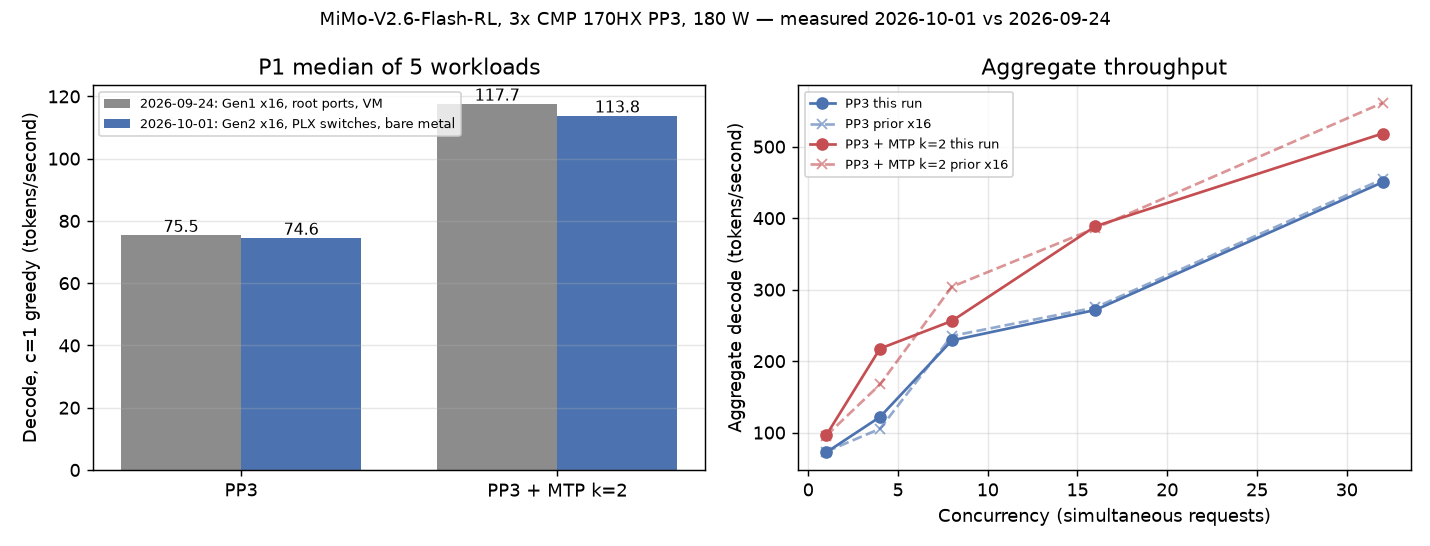

In [7]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2))
x = range(len(CFGS)); w = 0.38
a1.bar([i - w / 2 for i in x], [p1m(old[c]["p1"]) for c in CFGS], w, label="2026-09-24: Gen1 x16, root ports, VM", color="#8c8c8c")
a1.bar([i + w / 2 for i in x], [p1m(new[c]["p1"]) for c in CFGS], w, label="2026-10-01: Gen2 x16, PLX switches, bare metal", color="#4c72b0")
for i, c in enumerate(CFGS):
    a1.text(i - w / 2, p1m(old[c]["p1"]) + 1, f"{p1m(old[c]['p1']):.1f}", ha="center", fontsize=9)
    a1.text(i + w / 2, p1m(new[c]["p1"]) + 1, f"{p1m(new[c]['p1']):.1f}", ha="center", fontsize=9)
a1.set_xticks(list(x)); a1.set_xticklabels([LABEL[c] for c in CFGS]); a1.set_ylabel("Decode, c=1 greedy (tokens/second)")
a1.set_title("P1 median of 5 workloads"); a1.legend(fontsize=7); a1.grid(axis="y", alpha=.3)
for c, col in zip(CFGS, ["#4c72b0", "#c44e52"]):
    n = new[c]["conc"]["levels"]; o = old[c]["conc"]["levels"]
    a2.plot([l["concurrency"] for l in n], [l["aggregate_tok_s"] for l in n], marker="o", color=col, label=f"{LABEL[c]} this run")
    a2.plot([l["concurrency"] for l in o], [l["aggregate_tok_s"] for l in o], marker="x", ls="--", color=col, alpha=.6, label=f"{LABEL[c]} prior x16")
a2.set_xlabel("Concurrency (simultaneous requests)"); a2.set_ylabel("Aggregate decode (tokens/second)")
a2.set_title("Aggregate throughput"); a2.legend(fontsize=7); a2.grid(alpha=.3)
fig.suptitle("MiMo-V2.6-Flash-RL, 3x CMP 170HX PP3, 180 W — measured 2026-10-01 vs 2026-09-24", fontsize=10)
fig.tight_layout()
chart = os.path.join("..", "assets", "charts", EXPERIMENT)
fig.savefig(chart + ".png", dpi=130); fig.savefig(chart + ".svg"); plt.close(fig)
display(Image(chart + ".png"))

## 3. Reproduce

Identical to section 5 of the [2026-09-22 notebook](2026-09-22-mimo-v2.6-flash-4card-pp4-vllm.ipynb)
(weights, `VLLM_PP_LAYER_PARTITION=17,16,15`, patch mounts, `--gpu-memory-utilization 0.97
--max-model-len 32768 --max-num-seqs 32`), with the image pinned by digest:

```bash
P=$PWD/results/2026-09-22-mimo-v2.6-flash-4card-pp4-vllm/patches
docker run -d --name mimo --gpus all --shm-size 32g \
  -e VLLM_PP_LAYER_PARTITION=17,16,15 -e VLLM_USE_V2_MODEL_RUNNER=1 \
  -v <weights>:/models \
  -v $P/mimo_v2.py:/usr/local/lib/python3.12/dist-packages/vllm/model_executor/models/mimo_v2.py:ro \
  -v $P/mimo_v2_mtp.py:/usr/local/lib/python3.12/dist-packages/vllm/model_executor/models/mimo_v2_mtp.py:ro \
  -p 127.0.0.1:8000:8000 ghcr.io/pixelml/club-170hx@sha256:62f612b49614523e6a46e1493d35d3efd1f363917129d38cc923a31053693bfb \
  --model /models/mimo-v2.6-flash-rl --served-model-name mimo-v2.6-flash \
  --pipeline-parallel-size 3 --trust-remote-code --gpu-memory-utilization 0.97 \
  --reasoning-parser mimo --max-num-seqs 32 --max-model-len 32768 \
  --speculative-config '{"method":"mimo_mtp","num_speculative_tokens":2}'
```

Plain PP3: drop `VLLM_USE_V2_MODEL_RUNNER`, the MTP mount and `--speculative-config`. Bench with
the previous notebook's `tools/gate.py`, `tools/bench_mimo.py --protocol p1|p2`,
`tools/conc_sweep.py`, and this bundle's `tools/prefill_probe.py`.

Host notes: the unlocked cards share PLX switches here, so the unlock needs the BAR1-resize
serialization patch from the 2026-10-01 interconnect notebook; the WPR fix from the previous
notebook is already upstream in the unlock version used.

## 4. Appendix

<details>
<summary>Differences from the prior run, limitations</summary>

- Prior run: 3 cards at Gen1 x16 on CPU root ports, inside a VM (passthrough), 180 W. This run:
  3 cards at Gen2 x16 behind two PLX switches, bare metal, 180 W, no P2P. Pipeline stages hand
  activations between cards through host memory in both cases.
- Chassis fans were held at a fixed high duty for the run (one card's slot has weak airflow;
  a separate run on that card hit the 80 °C stop). The 80 °C / Xid guard was active; see
  `runs/*/telemetry.csv`.
- Prefill here uses a fresh ~21.5k-token prompt per sample (`tools/prefill_probe.py`); the
  prior run's prefill receipts are not in the repository, so no prefill comparison is made.
- DFlash k=7 was not re-run.
- MTP k=2 mean acceptance length during the concurrency sweep: 2.20–2.24 (`runs/pp3-mtp2/spec-stats.txt`), in line with the prior run's ~2.1.

</details>